In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import csv

# Configuration
RESULTS_DIR = Path("../results")


In [2]:
# Define time range for concatenating measurements
start_str = "2026-01-05 23:59:02"  # inclusive start
end_str = "2026-01-06 09:00:00"  

type_meas = "full_swing" # full_swing

fourier_analysis = False
plot_data = True

interferometry_data_skipping_factor = 100


In [3]:
%matplotlib widget

In [ ]:
start_dt = datetime.datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S") + datetime.timedelta(seconds=5)
end_dt = datetime.datetime.strptime(end_str, "%Y-%m-%d %H:%M:%S") - datetime.timedelta(seconds=0)
if end_dt <= start_dt:
    raise ValueError("End datetime must be after start datetime")

# Find all files in the specified time range



In [5]:
def files_list(type_meas, exclude_set = None, start_dt = start_dt, end_dt = end_dt):
    files_in_range = []
    if exclude_set is None:
        exclude_set = []
    current_date = start_dt.date()
    while current_date <= end_dt.date():
        print(current_date)
        for file in sorted((RESULTS_DIR / current_date.strftime("%Y") / current_date.strftime("%m") / current_date.strftime("%d")).glob(f"{type_meas}_*.json")):
            # Skip if file is in exclusion list
            if file.name in exclude_set:
                print(f"  Excluding: {file.name}")
                continue
            
            # print(file.name)
            try:
                stamp = file.stem.split("_")[-1]  # expects v_meas_YYYYMMDD-HHMMSS.json
                dt = datetime.datetime.strptime(stamp, "%Y%m%d-%H%M%S")
                # print(dt)
            except ValueError:
                continue  # skip files that don't match the timestamp pattern
            if start_dt <= dt <= end_dt:
                print(dt)
                files_in_range.append((dt, file))
        current_date += datetime.timedelta(days=1)
    
    return files_in_range

In [6]:
exclude_set = ["full_swing_20260106-000022.json","full_swing_20260106-000310.json","full_swing_20260106-005157.json", 'full_swing_20260106-014647.json', 'full_swing_20260106-021808.json', 'full_swing_20260106-021841.json', 'full_swing_20260106-025901.json',"full_swing_20260106-030327.json"]
# exclude_set = []
files_in_range_full_swing = files_list("full_swing", exclude_set = exclude_set)

if not files_in_range_full_swing:
    print("No files found in the specified range.")
else:
    # Load and concatenate data from all files
    concat_time_full_swing = []
    concat_voltage_min_full_swing = []
    concat_voltage_max_full_swing = []
    concat_voltage_avg_full_swing = []
    concat_voltage_polarization_max_full_swing = []
    concat_voltage_polarization_min_full_swing = []
    base_dt = files_in_range_full_swing[0][0]  # anchor absolute time to the first capture

    for dt, file in files_in_range_full_swing:
        with open(file, "r") as f:
            d = json.load(f)
        t = np.array(d["time_s"], dtype=float)
        v = np.array(d["voltage_data_v"], dtype=float)
        if len(t) == 0 or len(v) == 0:
            continue

        # Offset this capture so its start reflects the true wall-clock interval
        offset = (dt - base_dt).total_seconds()
        concat_time_full_swing.append([(t + offset)[0]])
        concat_voltage_min_full_swing.append([np.min(v)])
        concat_voltage_max_full_swing.append([np.max(v)])
        concat_voltage_avg_full_swing.append([np.mean(v)])
        concat_voltage_polarization_max_full_swing.append([(np.max(v) - np.mean(v))/np.mean(v)])
        concat_voltage_polarization_min_full_swing.append([((np.min(v) - np.mean(v))/np.mean(v))])

    if not concat_time_full_swing:
        print("All files in range were empty after parsing.")
    else:
        concat_time_full_swing = np.concatenate(concat_time_full_swing)
        concat_voltage_min_full_swing = np.concatenate(concat_voltage_min_full_swing)
        concat_voltage_max_full_swing = np.concatenate(concat_voltage_max_full_swing)
        concat_voltage_avg_full_swing = np.concatenate(concat_voltage_avg_full_swing)
        concat_voltage_polarization_max_full_swing = np.concatenate(concat_voltage_polarization_max_full_swing)
        concat_voltage_polarization_min_full_swing = np.concatenate(concat_voltage_polarization_min_full_swing)
        
        print(f"Loaded {len(files_in_range_full_swing)} files")
        print(f"Total data points: {len(concat_voltage_min_full_swing)}")
        print(f"Time range: {base_dt} to {base_dt + datetime.timedelta(seconds=concat_time_full_swing[-1])}")



2026-01-05
2026-01-05 23:59:05
2026-01-05 23:59:07
2026-01-05 23:59:10
2026-01-05 23:59:13
2026-01-05 23:59:16
2026-01-05 23:59:19
2026-01-05 23:59:22
2026-01-05 23:59:25
2026-01-05 23:59:28
2026-01-05 23:59:30
2026-01-05 23:59:33
2026-01-05 23:59:35
2026-01-05 23:59:38
2026-01-05 23:59:41
2026-01-05 23:59:43
2026-01-05 23:59:46
2026-01-05 23:59:49
2026-01-05 23:59:53
2026-01-05 23:59:56
2026-01-05 23:59:58
2026-01-06
2026-01-06 00:00:01
2026-01-06 00:00:04
2026-01-06 00:00:06
2026-01-06 00:00:09
2026-01-06 00:00:12
2026-01-06 00:00:14
2026-01-06 00:00:17
2026-01-06 00:00:20
  Excluding: full_swing_20260106-000022.json
2026-01-06 00:00:26
2026-01-06 00:00:29
2026-01-06 00:00:32
2026-01-06 00:00:34
2026-01-06 00:00:37
2026-01-06 00:00:40
2026-01-06 00:00:43
2026-01-06 00:00:45
2026-01-06 00:00:48
2026-01-06 00:00:51
2026-01-06 00:00:54
2026-01-06 00:00:56
2026-01-06 00:01:00
2026-01-06 00:01:03
2026-01-06 00:01:05
2026-01-06 00:01:08
2026-01-06 00:01:10
2026-01-06 00:01:13
2026-01-06 00

In [7]:

print(concat_voltage_max_full_swing)
print(concat_voltage_avg_full_swing)
print(concat_voltage_min_full_swing)

[-0.0272146   0.10553922  0.10553922 ...  0.10553922  0.10553922
  0.10622001]
[-0.13408354  0.05581693  0.05591059 ...  0.05668327  0.05664018
  0.05673282]
[-0.25561925  0.00614406  0.00614406 ...  0.00784603  0.00784603
  0.00750563]


In [8]:
exclude_set = ["v_meas_20260106-005342.json","v_meas_20260106-011322.json","v_meas_20260106-012006.json","v_meas_20260106-012147.json", 'v_meas_20260106-013430.json', 'v_meas_20260106-013718.json', 'v_meas_20260106-015008.json', 'v_meas_20260106-024138.json', 'v_meas_20260106-024607.json']
files_in_range_interferometry = files_list("v_meas", exclude_set = exclude_set)


if not files_in_range_interferometry:
    print("No files found in the specified range.")

elif len(files_in_range_interferometry) != len(files_in_range_full_swing):
    print("Number of files in range are not the same")
    print(f"Full swing: {len(files_in_range_full_swing)}")
    print(f"Interferometry: {len(files_in_range_interferometry)}")
    Warning("Number of files in range are not the same")
    
else:
    # Load and concatenate data from all files
    concat_time_interferometry = []
    concat_voltage_interferometry = []
    base_dt = files_in_range_interferometry[0][0]  # anchor absolute time to the first capture

    for dt, file in files_in_range_interferometry:
        with open(file, "r") as f:
            d = json.load(f)
        t = np.array(d["time_s"], dtype=float)[::interferometry_data_skipping_factor]
        v = np.array(d["voltage_data_v"], dtype=float)[::interferometry_data_skipping_factor]
        if len(t) == 0 or len(v) == 0:
            continue

        # Offset this capture so its start reflects the true wall-clock interval
        offset = (dt - base_dt).total_seconds()
        concat_time_interferometry.append(t + offset)
        concat_voltage_interferometry.append(v)

    if not concat_time_interferometry:
        print("All files in range were empty after parsing.")
    else:
        concat_time_interferometry = np.concatenate(concat_time_interferometry)
        concat_voltage_interferometry = np.concatenate(concat_voltage_interferometry)
        
        print(f"Loaded {len(files_in_range_interferometry)} files")
        print(f"Total data points: {len(concat_voltage_interferometry)}")
        print(f"Time range: {base_dt} to {base_dt + datetime.timedelta(seconds=concat_time_interferometry[-1])}")

2026-01-05
2026-01-05 23:59:06
2026-01-05 23:59:09
2026-01-05 23:59:11
2026-01-05 23:59:14
2026-01-05 23:59:18
2026-01-05 23:59:21
2026-01-05 23:59:23
2026-01-05 23:59:26
2026-01-05 23:59:29
2026-01-05 23:59:32
2026-01-05 23:59:34
2026-01-05 23:59:37
2026-01-05 23:59:39
2026-01-05 23:59:42
2026-01-05 23:59:45
2026-01-05 23:59:48
2026-01-05 23:59:51
2026-01-05 23:59:54
2026-01-05 23:59:57
2026-01-06
2026-01-06 00:00:00
2026-01-06 00:00:02
2026-01-06 00:00:05
2026-01-06 00:00:08
2026-01-06 00:00:10
2026-01-06 00:00:13
2026-01-06 00:00:16
2026-01-06 00:00:19
2026-01-06 00:00:21
2026-01-06 00:00:28
2026-01-06 00:00:31
2026-01-06 00:00:33
2026-01-06 00:00:36
2026-01-06 00:00:39
2026-01-06 00:00:42
2026-01-06 00:00:44
2026-01-06 00:00:47
2026-01-06 00:00:50
2026-01-06 00:00:52
2026-01-06 00:00:55
2026-01-06 00:00:59
2026-01-06 00:01:01
2026-01-06 00:01:04
2026-01-06 00:01:07
2026-01-06 00:01:09
2026-01-06 00:01:12
2026-01-06 00:01:15
2026-01-06 00:01:17
2026-01-06 00:01:20
2026-01-06 00:01:2

In [ ]:
# These two cells are to find data where there is missing data

In [ ]:
# dt_list_interferometry = [dt for dt, file in files_in_range_interferometry]
# dt_list_full_swing = [dt for dt, file in files_in_range_full_swing]

# a = [1]*len(dt_list_interferometry)
# b = [2]*len(dt_list_full_swing)
# type_list = a + b
# # print(type(type_list))
# date_list = dt_list_interferometry + dt_list_full_swing

# sorted_list = sorted(zip(date_list, type_list))

# sorted_date_list, sorted_type_list = zip(*sorted_list)


# print(type(sorted_type_list))
# sorted_type_list = list(sorted_type_list)

# modified_list = sorted_type_list[1:] + [3]

# # print(len(modified_list),len(sorted_type_list))

# print(np.where(np.array(modified_list) - np.array(sorted_type_list)==0))

# dt_ammend_list = [sorted_date_list[i] for i in np.where(np.array(modified_list) - np.array(sorted_type_list)==0)[0]]
# print(dt_ammend_list)






In [ ]:
# dt_list_interferometry = [dt for dt, file in files_in_range_interferometry]
# dt_list_full_swing = [dt for dt, file in files_in_range_full_swing]

# a = [file.name for dt, file in files_in_range_interferometry]
# b = [file.name for dt, file in files_in_range_full_swing]
# type_list = a + b
# # print(type(type_list))
# date_list = dt_list_interferometry + dt_list_full_swing

# sorted_list = sorted(zip(date_list, type_list))

# sorted_date_list, sorted_file_list = zip(*sorted_list)

# dt_ammend_list = [sorted_date_list[i] for i in np.where(np.array(modified_list) - np.array(sorted_type_list)==0)[0]]
# file_ammend_list = [sorted_file_list[i+1] for i in np.where(np.array(modified_list) - np.array(sorted_type_list)==0)[0]]
# print(file_ammend_list)

In [ ]:
# dt_list_interferometry = [dt for dt, file in files_in_range_interferometry]
# dt_list_full_swing = [dt for dt, file in files_in_range_full_swing]

# a = [file.name for dt, file in files_in_range_interferometry]
# b = [file.name for dt, file in files_in_range_full_swing]
# type_list = a + b
# # print(type(type_list))
# date_list = dt_list_interferometry + dt_list_full_swing

# sorted_list = sorted(zip(date_list, type_list))

# # sorted_date_list, sorted_type_list = zip(*sorted_list)

# for sorted_date_list, sorted_type_list in sorted_list:
#     print(sorted_date_list, sorted_type_list)



In [9]:
def extending_data(data,factor,symmetric=True):
    if symmetric:
        return np.concatenate([np.repeat([data[0]],np.floor(factor/2)), np.repeat(data[1:],factor), np.repeat([data[-1]],np.ceil(factor/2))])
    else:
        return np.repeat(data, factor)
    
    

In [10]:
if not(len(concat_time_interferometry)/len(concat_time_full_swing)).is_integer():
    print("Number of points in interferometry is not a multiple of full swing")
    
else:
    factor = int(len(concat_time_interferometry)/len(concat_time_full_swing))
    print(f"Factor: {factor}")
    extended_voltage_avg_full_swing = extending_data(concat_voltage_avg_full_swing, factor, symmetric=True)
    extended_voltage_max_full_swing = extending_data(concat_voltage_max_full_swing, factor, symmetric=True)
    extended_voltage_min_full_swing = extending_data(concat_voltage_min_full_swing, factor, symmetric=True)
    cosine_phase = (concat_voltage_interferometry - extended_voltage_avg_full_swing)/(extended_voltage_max_full_swing - extended_voltage_avg_full_swing)

Factor: 51


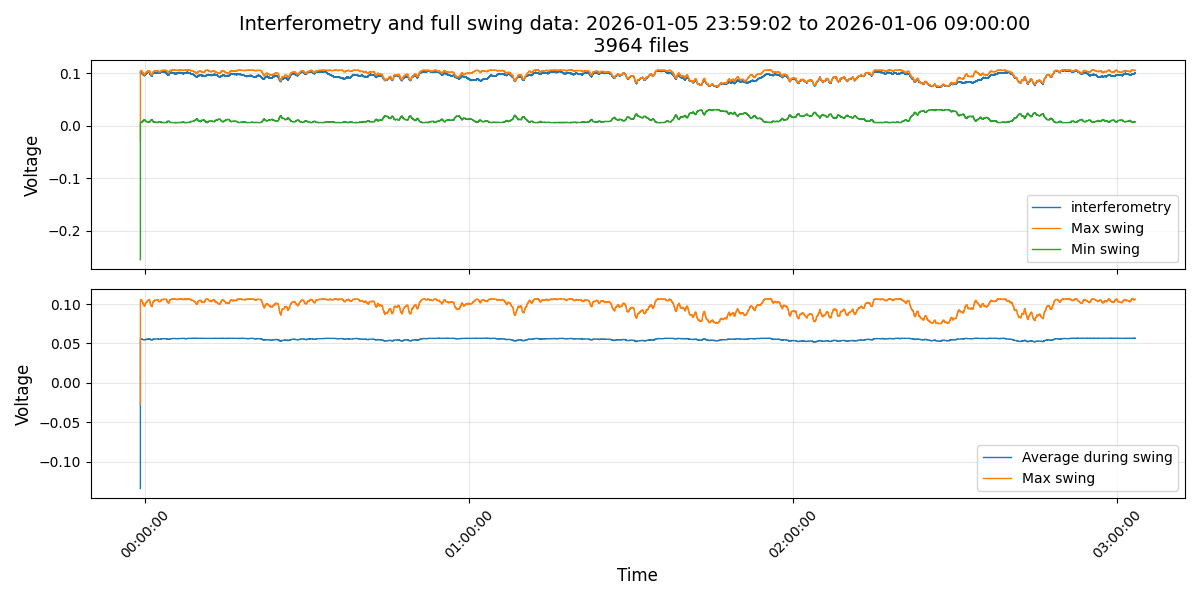


Files included (chronological):
  2026-01-05 23:59:06 -> v_meas_20260105-235906.json
  2026-01-05 23:59:09 -> v_meas_20260105-235909.json
  2026-01-05 23:59:11 -> v_meas_20260105-235911.json
  2026-01-05 23:59:14 -> v_meas_20260105-235914.json
  2026-01-05 23:59:18 -> v_meas_20260105-235918.json
  2026-01-05 23:59:21 -> v_meas_20260105-235921.json
  2026-01-05 23:59:23 -> v_meas_20260105-235923.json
  2026-01-05 23:59:26 -> v_meas_20260105-235926.json
  2026-01-05 23:59:29 -> v_meas_20260105-235929.json
  2026-01-05 23:59:32 -> v_meas_20260105-235932.json
  2026-01-05 23:59:34 -> v_meas_20260105-235934.json
  2026-01-05 23:59:37 -> v_meas_20260105-235937.json
  2026-01-05 23:59:39 -> v_meas_20260105-235939.json
  2026-01-05 23:59:42 -> v_meas_20260105-235942.json
  2026-01-05 23:59:45 -> v_meas_20260105-235945.json
  2026-01-05 23:59:48 -> v_meas_20260105-235948.json
  2026-01-05 23:59:51 -> v_meas_20260105-235951.json
  2026-01-05 23:59:54 -> v_meas_20260105-235954.json
  2026-01-05 

In [11]:
# Plot the concatenated data
if 'concat_time_interferometry' in locals() and 'cosine_phase' in locals() and len(concat_time_interferometry) > 0:
    # Convert time to actual datetime objects starting from the first measurement time
    # base_dt is the datetime of the first measurement
    # concat_time is in seconds relative to base_dt, so add timedelta to base_dt
    from datetime import timedelta
    import matplotlib.dates as mdates

    
    concat_datetime = [base_dt + timedelta(seconds=float(t)) for t in concat_time_interferometry]

    if plot_data:

        fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        # Plot min and max voltage on first axis
        axs[0].plot(concat_datetime[:], concat_voltage_interferometry[:], label='interferometry', linewidth=1)
        axs[0].plot(concat_datetime[:], extended_voltage_max_full_swing[:], label='Max swing', linewidth=1)
        axs[0].plot(concat_datetime[:], extended_voltage_min_full_swing[:], label='Min swing', linewidth=1)
        axs[0].set_ylabel("Voltage", fontsize=12)
        axs[0].legend()

        # Plot sum and diff voltage on second axis
        # axs[1].plot(concat_datetime[:], extended_voltage_max_full_swing[:], label='Max swing', linewidth=1)
        axs[1].plot(concat_datetime[:], extended_voltage_avg_full_swing, label='Average during swing', linewidth=1)
        axs[1].plot(concat_datetime[:], extended_voltage_max_full_swing[:], label='Max swing', linewidth=1)
        axs[1].set_xlabel("Time", fontsize=12)
        axs[1].set_ylabel("Voltage", fontsize=12)
        axs[1].legend()

        # Format x-axis to show time nicely
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
        plt.setp(axs[1].xaxis.get_majorticklabels(), rotation=45)
        axs[0].set_title(
            f"Interferometry and full swing data: {start_str} to {end_str} \n {len(files_in_range_interferometry)} files",
            fontsize=14,
        )
        for ax in axs:
            ax.grid(True, alpha=0.3)
        
        
        plt.tight_layout()
        plt.savefig(f"polarization_{start_str}_{end_str}.png")
        plt.show()

   
    print("\nFiles included (chronological):")
    for dt, file in files_in_range_interferometry:
        print(f"  {dt} -> {file.name}")
else:
    print("No data loaded. Please run the data loading cell first.")

In [ ]:
# Plot cosine_phase
if 'concat_time_interferometry' in locals() and 'cosine_phase' in locals() and len(concat_time_interferometry) > 0:
    from datetime import timedelta
    import matplotlib.dates as mdates
    
    concat_datetime = [base_dt + timedelta(seconds=float(t)) for t in concat_time_interferometry]
    
    # Calculate maximum phase shift
    average_phase = 180/np.pi * np.arccos(np.mean(cosine_phase))
    max_phase_shift = 180/np.pi * np.arccos(np.min(cosine_phase)) - 180/np.pi * (np.arccos(min([1,np.max(cosine_phase)])))
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(concat_datetime, cosine_phase, label='cosine_phase', linewidth=1)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Cosine Phase", fontsize=12)
    ax.set_title(
        f"Cosine Phase: {start_str} to {end_str}\nMax Phase Shift: {max_phase_shift:.2f}°",
        fontsize=14,
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add text annotation with maximum phase shift
    ax.text(0.02, 0.98, f'Max Phase Shift: {max_phase_shift:.2f}°', 
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.text(0.02, 0.91, f'Average Phase: {average_phase:.2f}°', 
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Format x-axis to show time nicely
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"cosine_phase_{start_str}_{end_str}.png")
    plt.show()
    
    print(f"Maximum phase shift: {max_phase_shift:.2f}°")
else:
    print("No data loaded. Please run the data loading cell first.")


In [ ]:
min([1,np.arccos(np.max(cosine_phase))])

In [ ]:
# Fourier analysis of cosine_phase_sparse
if fourier_analysis and 'concat_time_interferometry' in locals() and 'cosine_phase' in locals() and len(concat_time_interferometry) > 0:
    # Create sparse version of cosine_phase for Fourier analysis
    cosine_phase_sparse = cosine_phase[::10] 
    concat_time_interferometry_sparse = concat_time_interferometry[::10]
    
    # Subtract the mean from the data
    demeaned_cosine_phase = cosine_phase_sparse - np.mean(cosine_phase_sparse)
    
    # Apply Hamming window before FFT
    hamming_window = np.hamming(len(demeaned_cosine_phase))
    windowed_cosine_phase = demeaned_cosine_phase * hamming_window
    
    # Calculate sampling rate from time data
    # Assuming time is in seconds and measurements are evenly spaced
    if len(concat_time_interferometry_sparse) > 1:
        dt = np.mean(np.diff(concat_time_interferometry_sparse))  # Average time step in seconds
        sampling_rate = 1.0 / dt  # Sampling rate in Hz
    else:
        sampling_rate = 1.0  # Default if only one point
        dt = 1.0
    
    # Perform FFT on windowed data
    fft_values = np.fft.fft(windowed_cosine_phase)
    fft_magnitude = np.abs(fft_values)
    
    # Calculate frequency axis
    frequencies = np.fft.fftfreq(len(windowed_cosine_phase), d=dt)
    
    # Only plot positive frequencies (up to Nyquist frequency), excluding DC component
    positive_freq_idx = (frequencies > 0) & (frequencies <= sampling_rate/2)
    frequencies_positive = frequencies[positive_freq_idx]
    fft_magnitude_positive = fft_magnitude[positive_freq_idx]
    
    # Convert frequencies to periods (in seconds)
    periods_positive = 1.0 / frequencies_positive
    
    # Sort by period (ascending) for better visualization
    sort_idx = np.argsort(periods_positive)
    periods_sorted = periods_positive[sort_idx]
    fft_magnitude_sorted = fft_magnitude_positive[sort_idx]
    
    # Plot Fourier spectrum in linear scale with period on x-axis (log scale)
    plt.figure(figsize=(12, 6))
    plt.plot(periods_sorted/60, fft_magnitude_sorted, linewidth=1)
    plt.xscale('log')
    plt.xlabel("Period (min)", fontsize=12)
    plt.ylabel("Magnitude (linear scale)", fontsize=12)
    plt.title(
        f"Fourier Transform of Cosine Phase (sparse): {start_str} to {end_str}",
        fontsize=14,
    )
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(f"fourier_cosine_phase_{start_str}_{end_str}.png")
    plt.show()
    
    # Print some statistics
    print("\nFourier Analysis Statistics (cosine_phase_sparse):")
    print(f"  Original data points: {len(cosine_phase)}")
    print(f"  Sparse data points: {len(cosine_phase_sparse)} (downsampled by factor of 10)")
    print(f"  Sampling rate: {sampling_rate:.6f} Hz")
    print(f"  Nyquist frequency: {sampling_rate/2:.6f} Hz")
    print(f"  Number of points in FFT: {len(windowed_cosine_phase)}")
    print(f"  Frequency resolution: {frequencies_positive[1] - frequencies_positive[0]:.6f} Hz")
    print(f"  Max magnitude: {np.max(fft_magnitude_positive):.6f}")
    max_mag_idx = np.argmax(fft_magnitude_positive)
    print(f"  Frequency at max magnitude: {frequencies_positive[max_mag_idx]:.6f} Hz")
    print(f"  Period at max magnitude: {periods_positive[max_mag_idx]:.6f} s ({periods_positive[max_mag_idx]/60:.2f} min)")
else:
    print("No data loaded. Please run the data loading cell first.")


# Not Used

In [ ]:
# # Calculate and plot the phase
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     # Select the data range (same as used in phase function definition)
#     start_idx = 400  # Starting from 4 hours in (assuming 1000 samples per second)
#     time_selected = concat_time[start_idx:]
#     voltage_selected = concat_voltage[start_idx:]
    
#     # Calculate phase using the phase function
#     phase_shift = phase(voltage_selected, time_selected, v_min, v_max)
    
#     # Plot the phase
#     plt.figure(figsize=(12, 6))
#     plt.plot(time_selected, phase_shift, linewidth=0.5)
#     plt.xlabel("Time (s)", fontsize=12)
#     plt.ylabel("Phase (radians)", fontsize=12)
#     plt.title("Phase Shift vs Time", fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()
    
#     # # Print phase statistics
#     # print("\nPhase statistics:")
#     # print(f"  Min phase: {np.min(phase_shift):.6f} rad ({np.min(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Max phase: {np.max(phase_shift):.6f} rad ({np.max(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Mean phase: {np.mean(phase_shift):.6f} rad ({np.mean(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Phase range: {np.max(phase_shift) - np.min(phase_shift):.6f} rad ({(np.max(phase_shift) - np.min(phase_shift)) * 180 / np.pi:.2f}°)")
#     # print(f"  Number of points: {len(phase_shift)}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [ ]:
# # Export concat_time and concat_voltage data
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     import csv
    
#     # Create filename with timestamp range
#     filename_base = f"concatenated_data_{start_str.replace(' ', '_').replace(':', '-')}_to_{end_str.replace(' ', '_').replace(':', '-')}"
    
#     # Option 1: Export to CSV (easy to open in Excel/spreadsheet programs)
#     export_filename_csv = f"{filename_base}.csv"
#     with open(export_filename_csv, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(['time_s', 'voltage_v'])  # Header
#         # Write data in chunks to handle large files efficiently
#         chunk_size = 10000
#         for i in range(0, len(concat_time), chunk_size):
#             chunk = np.column_stack([concat_time[i:i+chunk_size], concat_voltage[i:i+chunk_size]])
#             writer.writerows(chunk)
#     print(f"Data exported to CSV: {export_filename_csv}")
#     print(f"  Rows: {len(concat_time)}")
    
#     # Option 2: Export to NPZ (numpy compressed format - preserves precision and is efficient)
#     export_filename_npz = f"{filename_base}.npz"
#     # Save base_dt as ISO format string for easy reconstruction
#     np.savez(export_filename_npz, 
#              concat_time=concat_time, 
#              concat_voltage=concat_voltage, 
#              base_dt_str=base_dt.isoformat(),
#              start_str=start_str,
#              end_str=end_str)
#     print(f"Data exported to NPZ: {export_filename_npz}")
#     print(f"  To load: data = np.load('{export_filename_npz}'); time = data['concat_time']; voltage = data['concat_voltage']")
#     print(f"  base_dt: {base_dt.isoformat()}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [ ]:
# Exporting the data


In [ ]:
# v_min = 0.02489
# v_max = 0.0644

# v_min = min(v_min, np.min(concat_voltage[4*3600*1000:]))
# v_max = max(v_max, np.max(concat_voltage[4*3600*1000:]))


# def phase(v, t,v_min,v_max):
#     demeaned = v - (v_min + v_max)/2
#     swing = (v_max - v_min)/2
#     phase_shift = np.arcsin(demeaned/swing)
#     return phase_shift